In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../Data/Sample - Superstore.csv',  encoding='latin1')

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.shape

In [ ]:
df.isnull().sum()

In [ ]:
df.drop_duplicates()

In [ ]:
df.columns

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [ ]:
df.info()

In [15]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Year'] = df['Order Date'].dt.year

In [ ]:
df['Month'] = df['Order Date'].dt.month

In [ ]:
df['Day'] = df['Order Date'].dt.day

In [ ]:
total_sales = df['Sales'].sum()
print(f'Total Sales: {total_sales}')

In [ ]:
total_profit = df['Profit'].sum()
print(f'Total Profit: {total_profit}')

In [ ]:
total_orders = df['Order ID'].nunique()
print(f'Total Orders: {total_orders}')

In [ ]:
sales_by_category = df.groupby('Category')['Sales'].sum()
print(f'Sales by Category:\n{sales_by_category}')

In [ ]:
profit_by_category = df.groupby('Category')['Profit'].sum()
print(f'Profit by Category:\n{profit_by_category}')

In [ ]:
top_10_customers = df['Customer Name'].value_counts().head(10)
print(f'Top 10 Customers:\n{top_10_customers}')

In [17]:
# 📘 SECTION: SALES ANALYSIS
# Q1: Monthly Sales Trends
monthly_sales = df.groupby('Month')['Sales'].sum()
print(f'Monthly Sales Trends:\n{monthly_sales}')

Monthly Sales Trends:
Month
April        137762.1286
August       159044.0630
December     325293.5035
February      59751.2514
January       94924.8356
July         147238.0970
June         152718.6793
March        205005.4888
May          155028.8117
November     352461.0710
October      200322.9847
September    307649.9457
Name: Sales, dtype: float64


In [12]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Create Month column
df['Month'] = df['Order Date'].dt.month_name()

# Check result
print(df[['Order Date', 'Month']].head())

  Order Date     Month
0 2016-11-08  November
1 2016-11-08  November
2 2016-06-12      June
3 2015-10-11   October
4 2015-10-11   October


In [18]:
# Monthly profit trenda
monthly_profit = df.groupby('Month')['Profit'].sum()
print(f'Monthly Profit Trends:\n{monthly_profit}')

Monthly Profit Trends:
Month
April        11587.4363
August       21776.9384
December     43369.1919
February     10294.6107
January       9134.4461
July         13832.6648
June         21285.7954
March        28594.6872
May          22411.3078
November     35468.4265
October      31784.0413
September    36857.4753
Name: Profit, dtype: float64


In [19]:
# Q3: Best performing state
best_state = df.groupby('State')['Sales'].sum().idxmax()
print(f'Best Performing State: {best_state}')

Best Performing State: California


In [20]:
# Q4: Most profitable State
most_profitable_state = df.groupby('State')['Profit'].sum().idxmax()
print(f'Most Profitable State: {most_profitable_state}')

Most Profitable State: California


In [21]:
# Q5 : Top 10 Sales by sales
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)
print(f'Top 10 Products by Sales:\n{top_products}')

Top 10 Products by Sales:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [22]:
# Q6 : Most Loss-making products
most_loss_making_products = df.groupby('Product Name')['Profit'].sum().nsmallest(10)
print(f'Top 10 Most Loss-Making Products:\n{most_loss_making_products}')

Top 10 Most Loss-Making Products:
Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64


In [23]:
# 📘 SECTION: CUSTOMER ANALYSIS

# Q7: Top 10 Customers by Profit
top_customers_profit = df.groupby('Customer Name')['Profit'].sum().nlargest(10)
print(f'Top 10 Customers by Profit:\n{top_customers_profit}')

Top 10 Customers by Profit:
Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64


In [24]:
# Segment wise sales
segment_sales = df.groupby('Segment')['Sales'].sum()
print(f'Segment-wise Sales:\n{segment_sales}')

Segment-wise Sales:
Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64


In [25]:
# Q9: Region wise Profit
region_profit = df.groupby('Region')['Profit'].sum()
print(f'Region-wise Profit:\n{region_profit}')

Region-wise Profit:
Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64


In [16]:
# 📘 SECTION: PIVOT TABLES 🔥
# 🟢 Q10: Sales Pivot Table
sales_pivot = pd.pivot_table(
    df,
    values = 'Sales',
    index = 'Category',
    columns = 'Region',
    aggfunc = 'sum'
)

print(f'Sales Pivot Table:\n{sales_pivot}')

sales_pivot.to_csv('../outputs/sales_pivot.csv')

Sales Pivot Table:
Region               Central        East       South         West
Category                                                         
Furniture        163797.1638  208291.204  117298.684  252612.7435
Office Supplies  167026.4150  205516.055  125651.313  220853.2490
Technology       170416.3120  264973.981  148771.908  251991.8320


In [17]:
import os

os.listdir('../outputs')

['charts', 'sales_pivot.csv']

In [18]:
# Q11: Profit Pivot Table
profit_pivot = pd.pivot_table(
    df,
    values = 'Profit',
    index = 'Category',
    columns = 'Region',
    aggfunc = 'sum'
)
print(f'Profit Pivot Table:\n{profit_pivot}')

profit_pivot.to_csv('../outputs/profit_pivot.csv')

Profit Pivot Table:
Region              Central        East       South        West
Category                                                       
Furniture        -2871.0494   3046.1658   6771.2061  11504.9503
Office Supplies   8879.9799  41014.5791  19986.3928  52609.8490
Technology       33697.4320  47462.0351  19991.8314  44303.6496


In [19]:
import os

os.listdir('../outputs')

['charts', 'profit_pivot.csv', 'sales_pivot.csv']

In [5]:
# 📘 SECTION: RANKING
# Q12: Rank Customers By Sales
customer_rank = df.groupby('Customer Name')['Sales'].sum().reset_index()

customer_rank['Rank'] = customer_rank['Sales'].rank(ascending=False)

print(f'Customer Sales Ranking:\n{customer_rank.sort_values("Rank")}')

Customer Sales Ranking:
       Customer Name      Sales   Rank
686      Sean Miller  25043.050    1.0
730     Tamara Chand  19052.218    2.0
622     Raymond Buch  15117.339    3.0
757     Tom Ashbrook  14595.620    4.0
6      Adrian Barton  14473.571    5.0
..               ...        ...    ...
656       Roy Skaria     22.328  789.0
545  Mitch Gastineau     16.739  790.0
123     Carl Jackson     16.520  791.0
455     Lela Donovan      5.304  792.0
737    Thais Sissman      4.833  793.0

[793 rows x 3 columns]


In [3]:
import matplotlib.pyplot as plt

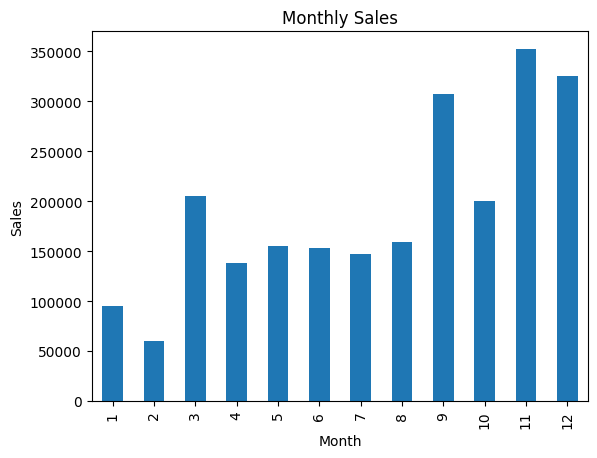

In [15]:
# 📘 STEP 2: Monthly Sales Chart
monthly_sale = df.groupby('Months')['Sales'].sum()
monthly_sale.plot(kind='bar')

plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.savefig('../outputs/charts/monthly_sales.png')

plt.show()

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [14]:
df['Months'] = df['Order Date'].dt.month

In [16]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

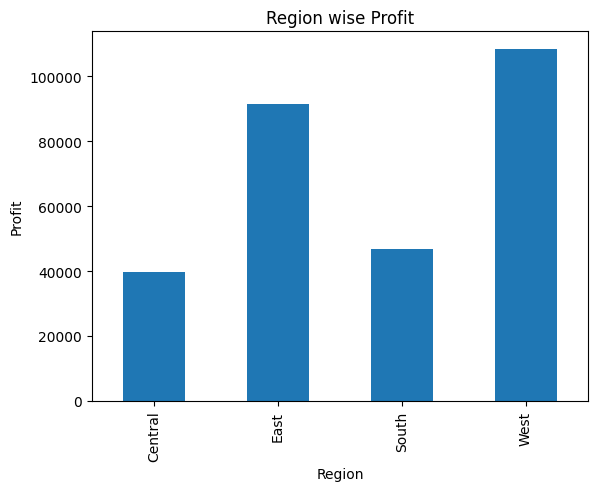

In [10]:
# 📘 STEP 3: Region Wise Profit Chart
region_profit = df.groupby('Region')['Profit'].sum()

region_profit.plot(kind='bar')

plt.title('Region wise Profit')
plt.xlabel('Region')
plt.ylabel('Profit')

plt.savefig('../outputs/charts/region_profit.png')

plt.show()

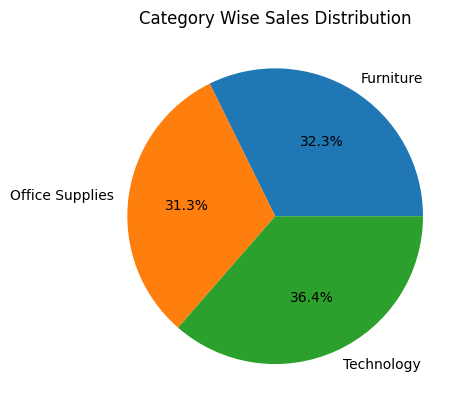

In [9]:
# 📘 STEP 4: Category Wise Sales Pie Chart
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Category Wise Sales Distribution')
plt.ylabel('')  # Hide y-axis label for better aesthetics

plt.savefig('../outputs/charts/category_sales_distribution.png')

plt.show()

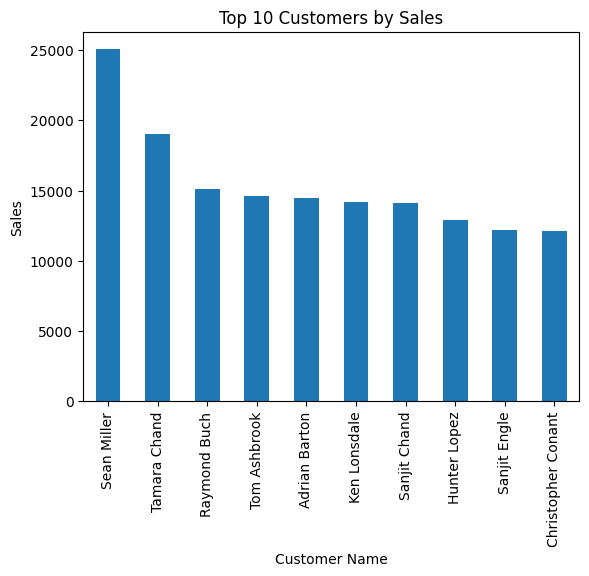

In [8]:
# 📘 STEP 5: Top 10 Customers Chart
top_customers = (
    df.groupby('Customer Name')['Sales']
    .sum()
    .nlargest(10)
)

top_customers.plot(kind='bar')

plt.title('Top 10 Customers by Sales')
plt.xlabel('Customer Name')
plt.ylabel('Sales')

plt.savefig('../outputs/charts/top_customers.png')

plt.show()

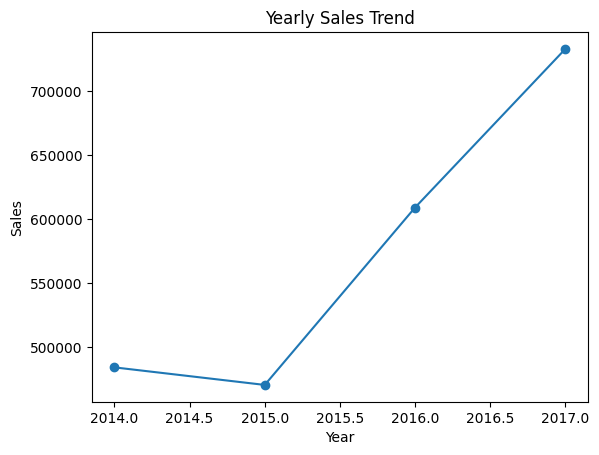

In [7]:
# 📘 STEP 6: Sales Trend Line Chart 🔥
yearly_sales = df.groupby('Year')['Sales'].sum()

yearly_sales.plot(kind='line', marker='o')

plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Sales')

plt.savefig('../outputs/charts/sales_trend.png')

plt.show()

In [20]:
df.to_csv('../outputs/cleaned_superstore.csv', index=False)

Business Insights

Technology category generated the highest sales revenue.
West region produced the maximum profit.
November was the best-performing month in terms of sales.
Some products generated negative profit, indicating loss-making items.
A small number of customers contribute a large portion of total sales.

# Sales Analysis Project

## Objective
Analyze sales performance and identify key business insights.

## Dataset Overview

## Data Cleaning

## Feature Engineering

## Sales Analysis

## Customer Analysis

## Profit Analysis

## Pivot Tables

## Visualizations

## Business Insights

## Conclusion

Conclusion

1. Technology category generated the highest sales.
2. West region produced the highest profit.
3. November was the strongest sales month.
4. Several products generated losses and need review.
5. Top customers contribute a significant portion of revenue.